#YOLOv9 para imagenes satelitales detección sistemas fotovoltaicos
##Proceso de entrenamiento en Colab

Este modelo primero vamos a verificar el entorno (esto por ser un espacio gratuito), e instalar el paquete Ultralytics

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!nvidia-smi
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.7/107.7 GB disk)


##Dataset

Para este caso usaremos un dataset elaborado por fuente propia de imagenes satelitales a un zoom de 19 en la plataforma SASPlanet con imagenes recortadas de 640x640

In [5]:
import os
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="3ktShi703GC4s4IjgvIe")
project = rf.workspace("daves-workspace-cvhyt").project("satellite-pv")
version = project.version(2)
dataset = version.download("yolov8")
print(f"✓ Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Satellite-PV-2 in yolov8:: 100%|██████████| 2057/2057 [00:00<00:00, 2810.59it/s]


✓ Dataset descargado en: /content/Satellite-PV-2


##Entrenamiento

Al usar un entorno gratuito, la limitación por cuenta al GPU no siempre logra entrenar todo el modelo, para guardar el progreso, vinculamos al drive y luego seguimos desde el último punto de partida.

In [ ]:
import os
from google.colab import drive
from ultralytics import YOLO

# 1. Definimos la ruta directa para los resultados de SEGMENTACIÓN
ruta_base = '/content/drive/MyDrive/Satelite_MID'
carpeta_resultados = os.path.join(ruta_base, 'Satelite_MID_YOLO_SEG')
os.makedirs(carpeta_resultados, exist_ok=True)

# 2. Cargamos el modelo preentrenado de segmentación (YOLOv9c-seg o YOLOv8s-seg)
# Nota: 'yolov9c-seg.pt' es la variante oficial de segmentación de la familia YOLOv9
model = YOLO('yolov9c-seg.pt')  # Si prefieres variante más ligera 's', puedes usar 'yolov8s-seg.pt'

# 3. Entrenamiento con polígonos
print(f"Iniciando entrenamiento de segmentación. Resultados en: {carpeta_resultados}")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=1000,
    patience=50,                     # Early Stopping
    imgsz=640,                       # Resolución nativa
    batch=16,                        # Optimizado para GPU T4
    project=carpeta_resultados,      # Carpeta destino en Drive
    name='run_yolo_seg_poligonos',   # Subcarpeta específica para esta corrida
    plots=True,
    save=True
)

print("¡Entrenamiento de segmentación completado! Revisa los archivos .pt y las curvas de máscara.")

Iniciando entrenamiento de segmentación. Resultados en: /content/drive/MyDrive/Satelite_MID/Satelite_MID_YOLO_SEG
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Satellite-PV-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1000, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

#Evaluación
Se evalúa el modelo con las siguientes métricas: Precision, Recall, F1-SCORE, mAP, mAP@50:95, IoU, mIoU, MAE, RMSE, $R^2$

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ruta_pesos = '/content/drive/MyDrive/Satelite_MID/Satelite_MID_YOLO_SEG/run_yolo_seg_poligonos/weights/best.pt'
carpeta_graficas = '/content/drive/MyDrive/Satelite_MID/Satelite_MID_YOLO_SEG/graficas_evaluacion'
os.makedirs(carpeta_graficas, exist_ok=True)

model = YOLO(ruta_pesos)

# Validación estándar de Ultralytics (Cajas y Máscaras)
print("Calculando métricas canónicas de detección y segmentación...")
metrics = model.val(data=f"{dataset.location}/data.yaml", split='val')

# Extracción de Precision, Recall y cálculo analítico de F1-Score
p_box = float(metrics.box.p[0])
r_box = float(metrics.box.r[0])
f1_box = 2 * (p_box * r_box) / (p_box + r_box + 1e-16)

p_seg = float(metrics.seg.p[0])
r_seg = float(metrics.seg.r[0])
f1_seg = 2 * (p_seg * r_seg) / (p_seg + r_seg + 1e-16)

# 3. Cálculo de IoU y Mean IoU (mIoU) a nivel de máscaras binarias
val_images_dir = os.path.join(dataset.location, "valid", "images")
val_labels_dir = os.path.join(dataset.location, "valid", "labels")
image_files = sorted([f for f in os.listdir(val_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

ious_list = []
y_true = []
y_pred = []

for img_file in image_files:
    img_path = os.path.join(val_images_dir, img_file)
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(val_labels_dir, label_file)

    # Cargar dimensiones de la imagen original
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    # Crear máscara binaria Ground Truth (GT)
    gt_mask = np.zeros((h, w), dtype=np.uint8)
    real_count = 0
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) > 5:  # Coordenadas poligonales
                    real_count += 1
                    coords = np.array([float(x) for x in parts[1:]], dtype=np.float32).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    cv2.fillPoly(gt_mask, [coords.astype(np.int32)], 1)
    y_true.append(real_count)

    # Inferencia del modelo y generación de máscara binaria Predicha
    results = model.predict(img_path, conf=0.25, verbose=False)[0]
    pred_mask = np.zeros((h, w), dtype=np.uint8)
    pred_count = len(results.boxes) if results.boxes is not None else 0
    y_pred.append(pred_count)

    if results.masks is not None:
        for seg in results.masks.xy:
            if len(seg) > 0:
                cv2.fillPoly(pred_mask, [seg.astype(np.int32)], 1)

    # Cálculo de Intersección sobre Unión (IoU) por imagen
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()

    if union == 0:
        iou = 1.0 if intersection == 0 else 0.0
    else:
        iou = intersection / union
    ious_list.append(iou)

ious_arr = np.array(ious_list)
miou = np.mean(ious_arr)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# -------------------------------------------------------------
# REPORTE DE RESULTADOS
# -------------------------------------------------------------
print("\n" + "="*55)
print("📊 RESULTADOS CONSOLIDADOS DE EVALUACIÓN")
print("="*55)
print(f"• Box Precision:              {p_box:.4f}")
print(f"• Box Recall:                 {r_box:.4f}")
print(f"• Box F1-Score:               {f1_box:.4f}")
print(f"• Box mAP@50:                 {metrics.box.map50:.4f}")
print(f"• Box mAP@50-95:              {metrics.box.map:.4f}")
print("-" * 55)
print(f"• Mask Precision:             {p_seg:.4f}")
print(f"• Mask Recall:                {r_seg:.4f}")
print(f"• Mask F1-Score:              {f1_seg:.4f}")
print(f"• Mask mAP@50:                {metrics.seg.map50:.4f}")
print(f"• Mask mAP@50-95:             {metrics.seg.map:.4f}")
print("-" * 55)
print(f"• mIoU (Mean IoU Máscaras):   {miou:.4f} ({miou*100:.2f}%)")
print(f"• MAE (Conteo Paneles):       {mae:.4f} paneles/imagen")
print(f"• RMSE:                       {rmse:.4f}")
print(f"• R² (Determinación):         {r2:.4f}")
print("="*55 + "\n")



Calculando métricas canónicas de detección y segmentación...
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv9c-seg summary (fused): 169 layers, 27,625,299 parameters, 0 gradients, 147.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1627.5±1075.5 MB/s, size: 107.6 KB)
val: Scanning /content/Satellite-PV-2/valid/labels... 84 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 672.7it/s 0.1s
val: New cache created: /content/Satellite-PV-2/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 64.8s/it 6:29
                   all         84       2028      0.726      0.598      0.646      0.347      0.616      0.459      0.462      0.176
Speed: 11.4ms preprocess, 4554.5ms inference, 0.0ms loss, 9.9ms postprocess per image
Results saved to /content/runs/segment/val

📊 RESULTADOS CONSOLIDADOS DE EVALUACIÓN
• Box Pr

#Gráficas

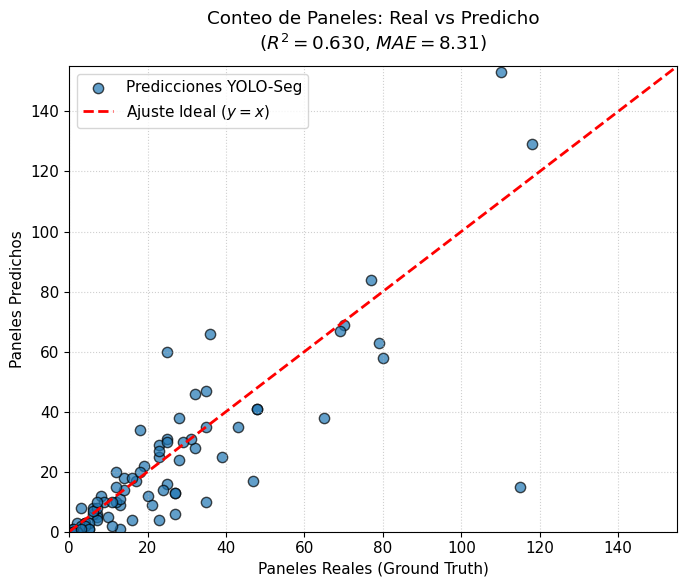

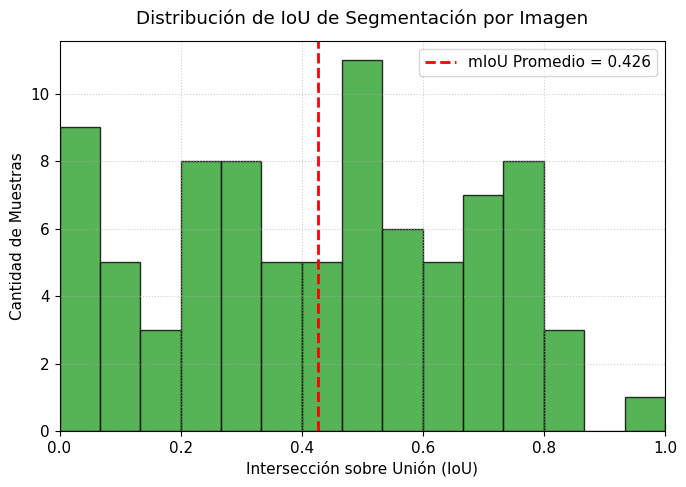

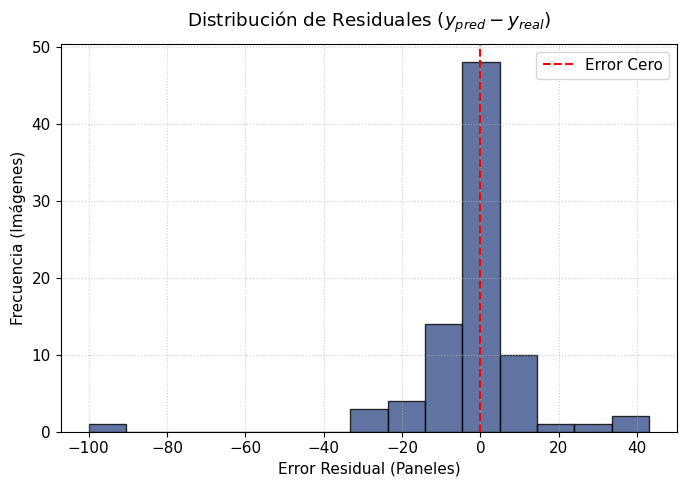

✓ Gráficas y métricas calculadas guardadas en: /content/drive/MyDrive/Satelite_MID/Satelite_MID_YOLO_SEG/graficas_evaluacion


In [7]:
# Estilos de gráficos
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

# -------------------------------------------------------------
# GRÁFICA 1: Dispersión Real vs Predicho (Scatter Plot)
# -------------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.scatter(y_true, y_pred, color='#1f77b4', alpha=0.7, edgecolors='k', s=55, label='Predicciones YOLO-Seg')
limite_max = max(y_true.max(), y_pred.max()) + 2
plt.plot([0, limite_max], [0, limite_max], '--r', linewidth=2, label='Ajuste Ideal ($y=x$)')
plt.title(f'Conteo de Paneles: Real vs Predicho\n($R^2 = {r2:.3f}$, $MAE = {mae:.2f}$)', pad=12)
plt.xlabel('Paneles Reales (Ground Truth)')
plt.ylabel('Paneles Predichos')
plt.xlim(0, limite_max)
plt.ylim(0, limite_max)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.savefig(os.path.join(carpeta_graficas, '1_dispersion_real_vs_pred.png'), dpi=300)
plt.show()

# -------------------------------------------------------------
# GRÁFICA 2: Distribución de IoU por Muestra
# -------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.hist(ious_arr, bins=15, color='#2ca02c', edgecolor='black', alpha=0.8)
plt.axvline(miou, color='red', linestyle='--', linewidth=2, label=f'mIoU Promedio = {miou:.3f}')
plt.title('Distribución de IoU de Segmentación por Imagen', pad=12)
plt.xlabel('Intersección sobre Unión (IoU)')
plt.ylabel('Cantidad de Muestras')
plt.xlim(0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig(os.path.join(carpeta_graficas, '2_distribucion_iou.png'), dpi=300)
plt.show()

# -------------------------------------------------------------
# GRÁFICA 3: Histograma de Errores Residuales
# -------------------------------------------------------------
errores = y_pred - y_true
plt.figure(figsize=(7, 5))
plt.hist(errores, bins=15, color='#3b528b', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error Cero')
plt.title('Distribución de Residuales ($y_{pred} - y_{real}$)', pad=12)
plt.xlabel('Error Residual (Paneles)')
plt.ylabel('Frecuencia (Imágenes)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig(os.path.join(carpeta_graficas, '3_distribucion_residuales.png'), dpi=300)
plt.show()

print(f"✓ Gráficas y métricas calculadas guardadas en: {carpeta_graficas}")